# 4 site exact solutions

Created 04/05/2025

Objectives:
* Find exact solutions with boundary operators of width 4.

# Package imports

In [1]:
import sys
sys.path.append('../../')

In [2]:
import h5py
from tenpy.tools import hdf5_io
import tenpy
import tenpy.linalg.np_conserved as npc

import os
import pickle

In [3]:
from itertools import chain, combinations, product
from collections import defaultdict
from functools import reduce
import re

In [4]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

from matplotlib.ticker import AutoMinorLocator, MultipleLocator

In [5]:
from tqdm import tqdm

In [6]:
import quimb as qu
import quimb.tensor as qtn

/Users/kierancooney/.pyenv/versions/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:54: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization.
  warnings.warn(
/Users/kierancooney/.pyenv/versions/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:36: UserWarning: Couldn't import `kahypar` - skipping from default hyper optimizer and using basic `labels` method instead.
  warnings.warn(
/Users/kierancooney/.pyenv/versions/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:73: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization.
  warnings.warn(


In [7]:
#from SPTOptimization.Optimizers.utils import to_npc_array

# Load data

In [8]:
DATA_DIR_1 = r"../../data/finite_cluster_x_transverse_to_product_stacked_cluster_200_site"
DATA_DIR_2 = r"../../data/finite_x_product_stacked_transverse_y_cluster_to_product_200_site"

In [9]:
loaded_data_1 = list()

for local_file_name in os.listdir(DATA_DIR_1):
    if local_file_name[-3:] == '.h5':
        f_name = r"{}/{}".format(DATA_DIR_1, local_file_name, ignore_unknown=False)
        with h5py.File(f_name, 'r') as f:
            data = hdf5_io.load_from_hdf5(f)
            loaded_data_1.append(data)

loaded_data_2 = list()

for local_file_name in os.listdir(DATA_DIR_2):
    if local_file_name[-3:] == '.h5':
        f_name = r"{}/{}".format(DATA_DIR_2, local_file_name, ignore_unknown=False)
        with h5py.File(f_name, 'r') as f:
            data = hdf5_io.load_from_hdf5(f)
            loaded_data_2.append(data)

FileNotFoundError: [Errno 2] No such file or directory: '../../data/finite_cluster_x_transverse_to_product_stacked_cluster_200_site'

In [ ]:
t_parameters = sorted(list(d['paramters']['interpolation'] for d in loaded_data_1))

In [ ]:
psi_dict = dict()

In [ ]:
for b in t_parameters:
    mps_psi = next(
        d['wavefunction']
        for d in loaded_data_1
        if d['paramters']['interpolation'] == b
    )

    psi_arrays = list()
    psi_arrays.append(mps_psi.get_B(0, 'Th')[0, ...].to_ndarray())
    for i in range(1, mps_psi.L-1):
        psi_arrays.append(mps_psi.get_B(i).to_ndarray())
    psi_arrays.append(mps_psi.get_B(mps_psi.L-1)[..., 0].to_ndarray())

    quimb_psi = (
        qtn
        .tensor_1d
        .MatrixProductState(psi_arrays, shape='lpr')
    )

    rounded_b = round(b, 1)
    psi_dict[rounded_b] = quimb_psi

for b in t_parameters:
    mps_psi = next(
        d['wavefunction']
        for d in loaded_data_2
        if d['paramters']['interpolation'] == b
    )

    psi_arrays = list()
    psi_arrays.append(mps_psi.get_B(0, 'Th')[0, ...].to_ndarray())
    for i in range(1, mps_psi.L-1):
        psi_arrays.append(mps_psi.get_B(i).to_ndarray())
    psi_arrays.append(mps_psi.get_B(mps_psi.L-1)[..., 0].to_ndarray())

    quimb_psi = (
        qtn
        .tensor_1d
        .MatrixProductState(psi_arrays, shape='lpr')
    )

    rounded_b = round(b, 1)
    psi_dict[rounded_b+1] = quimb_psi

# Definitons

In [ ]:
MAX_VIRTUAL_BOND_DIM = 8
MAX_INTERMEDIATE_VIRTUAL_BOND_DIM = 2*MAX_VIRTUAL_BOND_DIM
# MPO bond dim?
MAX_MPO_BOND_DIM = 50

SVD_CUTOFF = 1e-3

Define bosonic symmetries. Label by the group element added.

In [ ]:
np_I = np.array([[1,0],[0,1]])
np_X = np.array([[0,1],[1,0]])
np_Y = np.array([[0,-1j],[1j,0]])
np_Z = np.array([[1,0],[0,-1]])

In [ ]:
"""
npc_I = to_npc_array(np_I)
npc_X = to_npc_array(np_X)
npc_Y = to_npc_array(np_Y)
npc_Z = to_npc_array(np_Z)
"""

In [ ]:
def generate_problem_rdm(quimb_psi, symmetry_site_pairs, leftmost_symmetry_site,
                         num_symmetry_sites, num_boundary_sites,
                         antilinear=False, interior=False):
    # Being careful to conjugate the top tensors.
    q_top = quimb_psi.copy(deep=True)

    for i, s in symmetry_site_pairs:
        if antilinear:
            q_top[i].modify(
                data=q_top[i].data.conj()
            )
        q_top.gate(
            s,
            where=i,
            contract=False,
            inplace=True
        )

    shift = num_boundary_sites if interior else False
    left_boundary_sites = list(range(
        leftmost_symmetry_site-num_boundary_sites + shift,
        leftmost_symmetry_site+shift
    ))

    right_boundary_sites = list(range(
        leftmost_symmetry_site+num_symmetry_sites-shift,
        leftmost_symmetry_site+num_symmetry_sites+num_boundary_sites-shift
    ))
    
    indices_to_map = list(chain(left_boundary_sites, right_boundary_sites))

    index_mapping = {f'k{i}': f'b{i}' for i in indices_to_map}

    q_bottom = (
        quimb_psi
        .copy()
        .reindex(index_mapping, inplace=True)
        .conj()
    )

    sites_to_contract = {
        'left': list(range(leftmost_symmetry_site-num_boundary_sites+shift)),
        'middle': list(range(leftmost_symmetry_site+shift, leftmost_symmetry_site+num_symmetry_sites-shift)),
        'right': list(range(leftmost_symmetry_site+num_symmetry_sites+num_boundary_sites-shift, quimb_psi.L))
    }

    tags_to_contract = {
        k: [f'I{i}' for i in v]
        for k, v in sites_to_contract.items()
    }

    tn = (q_top & q_bottom)

    """
    tnc = (
        tn
        .contract(tags_to_contract['left'])
        .contract(tags_to_contract['middle'])
        .contract(tags_to_contract['right'])
    )
    """

    tnc = tn.contract()

    fuse_maps = [
        ('k_left', (f'k{i}' for i in left_boundary_sites)),
        ('b_left', (f'b{i}' for i in left_boundary_sites)),
        ('k_right', (f'k{i}' for i in right_boundary_sites)),
        ('b_right', (f'b{i}' for i in right_boundary_sites))
    ]

    tnc.fuse(fuse_maps, inplace=True)

    return tnc

## Optimisation functions

In [ ]:
def solve_for_boundary_operators(rdm, num_iters=20):
    scores = list()

    # Hard code warning
    u_left = qtn.tensor_builder.rand_tensor(
        (16, 16),
        inds=['k_left', 'b_left'],
        dtype='complex64'
    )

    u_right = qtn.tensor_builder.rand_tensor(
        (16, 16),
        inds=['k_right', 'b_right'],
        dtype='complex64'
    )

    for _ in range(num_iters):
        right_rdm = (rdm & u_left).contract()
        data = right_rdm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        u_right = qtn.Tensor(sol, inds = ['b_right', 'k_right'])
        
        left_rdm = (rdm & u_right).contract()
        data = left_rdm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        u_left = qtn.Tensor(sol, inds = ['b_left', 'k_left'])

    return (u_left, u_right), scores

## SPT functions

In [ ]:
def calculate_proj_rep_phase(state_g, left_schmidt_values_g, unitary_h,
                             state_gh,
                             left_environment,
                             max_virtual_bond_dim=MAX_VIRTUAL_BOND_DIM):
    prod_state, _ = multiply_stacked_unitaries_against_mps(
        unitary_h,
        state_g,
        left_schmidt_values_g,
        max_virtual_bond_dim
    )

    exp = inner_product_b_tensors(prod_state, state_gh, left_environment)

    return exp/(np.abs(exp))

In [ ]:
def get_proj_rep_phases(mps_tensors, left_schmidt_values, unitaries,
                        left_environment):
    mps_dict = {
        k: v for k, v in zip(symmetry_labels[1:], mps_tensors)
    }

    schmidt_vals_dict = {
        k: v for k, v in zip(symmetry_labels[1:], left_schmidt_values)
    }

    unitaries_dict = {
        k: v for k, v in zip(symmetry_labels[1:], unitaries)
    }

    out_phases = list()

    for a, b, c in group_products:
        phase = calculate_proj_rep_phase(
            mps_dict[a],
            schmidt_vals_dict[a],
            unitaries_dict[b],
            mps_dict[c],
            left_environment,
            max_virtual_bond_dim=MAX_VIRTUAL_BOND_DIM
        )

        out_phases.append(phase)

    return out_phases

In [ ]:
def get_right_proj_rep_phases_from_optimizers(optimizers):
    mps_tensors = [
        o.top_right_mps_tensors
        for o in optimizers[1:]
    ]

    left_schmidt_values = [
        o.current_right_side_left_schmidt_values
        for o in optimizers[1:]
    ]

    unitaries = [
        o.right_unitaries for o in optimizers[1:]
    ]

    left_environment = optimizers[0].right_side_left_symmetry_environment

    out = get_proj_rep_phases(
        mps_tensors,
        left_schmidt_values,
        unitaries,
        left_environment
    )

    return out

In [ ]:
def get_left_proj_rep_phases_from_optimizers(optimizers):
    mps_tensors = [
        o.top_left_mps_tensors
        for o in optimizers[1:]
    ]

    left_schmidt_values = [
        o.current_left_side_right_schmidt_values
        for o in optimizers[1:]
    ]

    unitaries = [
        o.left_unitaries for o in optimizers[1:]
    ]

    left_environment = optimizers[0].left_side_right_symmetry_environment

    out = get_proj_rep_phases(
        mps_tensors,
        left_schmidt_values,
        unitaries,
        left_environment
    )

    return out

## SPT extraction functions

In [ ]:
# Boolean indicates if the symmetry is anti-linear or not.
symmetry_actions = [
    ([np_I, np_I], False),
    ([np_X, np_I], False),
    ([np_I, np_X], True),
    ([np_X, np_X], True)
]

In [ ]:
symmetry_labels = [
    'I-I',
    'X-I',
    'I-XK',
    'X-XK'
]

In [ ]:
identity_element = 'I-I'

In [ ]:
e, a, b, c = symmetry_labels

In [ ]:
group_products = [
    (a, a, e),
    (b, b, e),
    (c, c, e),
    (a, b, c),
    (b, a, c),
    (a, c, b),
    (c, a, b),
    (b, c, a),
    (c, b, a),
]

In [ ]:
group_products_dict = {
    (a,b): c for a,b,c in group_products
}

In [ ]:
def multi_kron(arrays):
    return reduce(lambda X, Y: np.kron(X, Y), arrays)

In [ ]:
symmetry_actions_dict = {
    'I-I': (np.identity(16), False),
    'X-I': (multi_kron([np_X, np_I, np_X, np_I]), False),
    'I-XK': (multi_kron([np_I, np_X, np_I, np_X]), True),
    'X-XK': (multi_kron([np_X, np_X, np_X, np_X]), True)
}

In [ ]:
antilinear_dict = {
    e: False,
    a: False,
    b: True,
    c: True
}

In [ ]:
def relabel_mpo(mpo, k_label, b_label):
    site_locs = [
        int(k[1:]) for k in mpo.tag_map
        if bool(re.search(regex_p, k))
    ]

    k_in_indices = [f'k{i}' for i in site_locs]
    j_in_indices = [f'b{i}' for i in site_locs]

    k_out_indices = [f'{k_label}{i}' for i in site_locs]
    j_out_indices = [f'{b_label}{i}' for i in site_locs]

    mapping = dict(
        chain(
            zip(k_in_indices, k_out_indices),
            zip(j_in_indices, j_out_indices)
        )
    )

    mpo.reindex(mapping, inplace=True)

In [ ]:
def get_proj_rep_phase(rho, u_g, u_h, u_gh):
    m = (u_gh.conj().T) @ u_h @ u_g @ rho
    exp = np.trace(m)

    out = exp/np.abs(exp)

    return out

In [ ]:
np_I_4 = np.identity(16)

In [ ]:
# Duplicate definition here...!
def get_proj_rep_phases(rho, unitaries):
    out = list()

    unitaries_dict = {
        k: v for k, v in zip(symmetry_labels[1:], unitaries)
    }

    unitaries_dict['I-I'] = np_I_4

    out_phases = list()
    for a, b, c in group_products:
        phase = get_proj_rep_phase(
            rho,
            unitaries_dict[a],
            unitaries_dict[b],
            unitaries_dict[c]
        )

        out_phases.append(phase)

    return out_phases

In [ ]:
# Hard code warning!
# This code might be assuming the group is Abelian? Check Kapustin index formula in nonAbelian case.
def get_exterior_proj_rep_phase_kapustin_rule(rho, u_g, u_h, u_gh, g_symmetry_label):
    g_sym, antilinear = symmetry_actions_dict[g_symmetry_label]

    m_h = u_h.conj() if antilinear else u_h

    m = (
        (u_gh.conj().T)
        @ m_h
        @ u_g
        @ rho
    )
    exp = np.trace(m)

    out = exp/np.abs(exp)

    return out

In [ ]:
# Duplicate definition here...!
def get_exterior_proj_rep_phases_kapustin_rule(rho, unitaries):
    out = list()

    unitaries_dict = {
        k: v for k, v in zip(symmetry_labels[1:], unitaries)
    }

    unitaries_dict['I-I'] = np_I_4

    out_phases = list()
    for a, b, c in group_products:
        phase = get_exterior_proj_rep_phase_kapustin_rule(
            rho,
            unitaries_dict[a],
            unitaries_dict[b],
            unitaries_dict[c],
            a
        )

        out_phases.append(phase)

    return out_phases

In [ ]:
# Hard code warning!
# This code might be assuming the group is Abelian? Check Kapustin index formula in nonAbelian case.
def get_interior_proj_rep_phase(rho, u_g, u_h, u_gh, g_symmetry_label):
    g_sym, antilinear = symmetry_actions_dict[g_symmetry_label]

    m_h = u_h.conj() if antilinear else u_h

    m = (
        (u_gh.conj().T)
        @ g_sym
        @ m_h
        @ (g_sym.conj().T)
        @ u_g
        @ rho
    )
    exp = np.trace(m)

    out = exp/np.abs(exp)

    return out

In [ ]:
# Duplicate definition here...!
def get_interior_proj_rep_phases(rho, unitaries):
    out = list()

    unitaries_dict = {
        k: v for k, v in zip(symmetry_labels[1:], unitaries)
    }

    unitaries_dict['I-I'] = np_I_4

    out_phases = list()
    for a, b, c in group_products:
        phase = get_interior_proj_rep_phase(
            rho,
            unitaries_dict[a],
            unitaries_dict[b],
            unitaries_dict[c],
            a
        )

        out_phases.append(phase)

    return out_phases

# Calculate boundary operators
## Exterior

In [ ]:
num_boundary_sites=4
leftmost_symmetry_site=60
left_most_symmetry_site=leftmost_symmetry_site
num_symmetry_sites=80

symmetry_sites = list(range(
    leftmost_symmetry_site,
    leftmost_symmetry_site+num_symmetry_sites
))

In [ ]:
num_iterations = 3

In [ ]:
exterior_results_dict = dict()

for k1, psi in tqdm(psi_dict.items()):
    for k2, (bs, antilinear) in enumerate(symmetry_actions[1:], start=1):
        symmetry_site_pairs = (
            [(i, bs[0]) for i in range(left_most_symmetry_site, left_most_symmetry_site+num_symmetry_sites, 2)]
            + [(i, bs[1]) for i in range(left_most_symmetry_site+1, left_most_symmetry_site+num_symmetry_sites+1, 2)]
        )
    
        rdm = generate_problem_rdm(
            psi,
            symmetry_site_pairs,
            leftmost_symmetry_site,
            num_symmetry_sites,
            num_boundary_sites,
            antilinear=antilinear
        )
    
        (u_left, u_right), scores = solve_for_boundary_operators(
            rdm,
            num_iters=num_iterations
        )
    
        exterior_results_dict[(k1, k2)] = (u_left, u_right), scores

### Check results

In [ ]:
t_params = np.round(np.linspace(0, 2, 21), 1)

In [ ]:
t_params

In [ ]:
exterior_scores = list()
for t in t_params:

    exterior_scores.append([exterior_results_dict[(t, i)][1][-1] for i in [1,2,3]])

exterior_scores = np.array(exterior_scores)

In [ ]:
colors = [
    'tab:blue',
    'tab:orange',
    'tab:green'
]   

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))

for j, (col, label) in enumerate(zip(colors, symmetry_labels[1:])):
    plt.scatter(
        t_params,
        exterior_scores[:, j],
        color=col,
        label = label
    )

ax.xaxis.set_major_locator(
    matplotlib.ticker.MultipleLocator(0.2)
)

#ax.set_yscale('log')

ax.grid()
ax.grid(
    which='minor',
    axis='y',
    linestyle='--',
    zorder=-1e10
)
ax.set_axisbelow(True)

ax.set_ylabel(r'$\vert c\vert$', fontsize=13)
ax.set_xlabel('$B$', fontsize=13)

ax.legend(loc='lower center', title='Applied symmetry')

fig.suptitle(r'Final overlap $\vert c \vert$ with symmetry $g$ as a function of $B$')

#fig.savefig(r'plots/ed_cost_function_from_svd_bosonic.png', dpi=200)

Why are the boundary operator scores so good...?

In [ ]:
proj_rep_phases = list()

for t in tqdm(t_params):
    psi = psi_dict[t]

    rdm = generate_problem_rdm(
        psi,
        [],
        leftmost_symmetry_site,
        num_symmetry_sites,
        num_boundary_sites
    )

    left_rdm = (
        rdm
        .trace('b_right', 'k_right')
        .transpose('k_left', 'b_left')
        .data
    )
    right_rdm = (
        rdm
        .trace('b_left', 'k_left')
        .transpose('k_right', 'b_right')
        .data
    )

    unitary_pairs = [exterior_results_dict[(t, i)][0] for i in [1,2,3]]
    left_unitaries, right_unitaries = zip(*unitary_pairs)

    left_unitaries = [
        lu.transpose('b_left', 'k_left').data
        for lu in left_unitaries
    ]

    right_unitaries = [
        ru.transpose('b_right', 'k_right').data
        for ru in right_unitaries
    ]
    left_phases = get_proj_rep_phases(left_rdm, left_unitaries)
    right_phases = get_proj_rep_phases(right_rdm, right_unitaries)

    proj_rep_phases.append([left_phases, right_phases])

In [ ]:
proj_rep_phases = np.array(proj_rep_phases)

In [ ]:
proj_rep_phases.shape

In [ ]:
np.round(proj_rep_phases, 3)

In [ ]:
proj_rep_phases = list()

for t in tqdm(t_params):
    psi = psi_dict[t]

    rdm = generate_problem_rdm(
        psi,
        [],
        leftmost_symmetry_site,
        num_symmetry_sites,
        num_boundary_sites
    )

    left_rdm = (
        rdm
        .trace('b_right', 'k_right')
        .transpose('k_left', 'b_left')
        .data
    )
    right_rdm = (
        rdm
        .trace('b_left', 'k_left')
        .transpose('k_right', 'b_right')
        .data
    )

    unitary_pairs = [exterior_results_dict[(t, i)][0] for i in [1,2,3]]
    left_unitaries, right_unitaries = zip(*unitary_pairs)

    left_unitaries = [
        lu.transpose('b_left', 'k_left').data
        for lu in left_unitaries
    ]

    right_unitaries = [
        ru.transpose('b_right', 'k_right').data
        for ru in right_unitaries
    ]
    left_phases = get_exterior_proj_rep_phases_kapustin_rule(left_rdm, left_unitaries)
    right_phases = get_exterior_proj_rep_phases_kapustin_rule(right_rdm, right_unitaries)

    proj_rep_phases.append([left_phases, right_phases])

In [ ]:
proj_rep_phases = np.array(proj_rep_phases)

In [ ]:
proj_rep_phases.shape

In [ ]:
np.round(proj_rep_phases, 3)

## Interior

In [53]:
interior_results_dict = dict()

for k1, psi in tqdm(psi_dict.items()):
    for k2, (bs, antilinear) in enumerate(symmetry_actions[1:], start=1):
        symmetry_site_pairs = (
            [(i, bs[0]) for i in range(left_most_symmetry_site, left_most_symmetry_site+num_symmetry_sites, 2)]
            + [(i, bs[1]) for i in range(left_most_symmetry_site+1, left_most_symmetry_site+num_symmetry_sites+1, 2)]
        )
    
        rdm = generate_problem_rdm(
            psi,
            symmetry_site_pairs,
            leftmost_symmetry_site,
            num_symmetry_sites,
            num_boundary_sites,
            antilinear=antilinear,
            interior=True
            
        )
    
        (u_left, u_right), scores = solve_for_boundary_operators(
            rdm,
            num_iters=num_iterations
        )
    
        interior_results_dict[(k1, k2)] = (u_left, u_right), scores

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 21/21 [01:08<00:00,  3.28s/it]


In [54]:
interior_scores = list()
for t in t_params:

    interior_scores.append([interior_results_dict[(t, i)][1][-1] for i in [1,2,3]])

interior_scores = np.array(interior_scores)

In [55]:
interior_scores

array([[1.        , 1.        , 1.        ],
       [0.99380799, 1.        , 0.99380799],
       [0.96824589, 1.        , 0.96824589],
       [0.90351332, 1.        , 0.90351332],
       [0.74568893, 1.        , 0.74568893],
       [0.10881673, 1.        , 0.10967909],
       [0.74594755, 0.99999823, 0.74594666],
       [0.90351763, 1.        , 0.90351763],
       [0.96824592, 1.        , 0.96824592],
       [0.99380799, 1.        , 0.99380799],
       [1.        , 1.        , 1.        ],
       [1.        , 0.99855959, 0.99855959],
       [1.        , 0.99241536, 0.99241536],
       [1.        , 0.96745072, 0.96745072],
       [1.        , 0.91187853, 0.91187853],
       [1.        , 0.40402041, 0.40402041],
       [1.        , 0.94737346, 0.94737346],
       [1.        , 0.98839352, 0.98839352],
       [1.        , 0.9976646 , 0.9976646 ],
       [1.        , 0.99968356, 0.99968356],
       [1.        , 1.        , 1.        ]])

In [56]:
interior_scores - exterior_scores

array([[ 4.44089210e-16,  0.00000000e+00,  0.00000000e+00],
       [ 1.56541446e-14,  8.88178420e-16,  1.57651669e-14],
       [-1.84008364e-12,  5.55111512e-16, -1.84030569e-12],
       [ 5.81534820e-13, -1.55431223e-15,  5.82867088e-13],
       [-2.19280618e-06, -1.77635684e-15, -2.19280619e-06],
       [ 1.09851595e-02,  1.33226763e-15,  1.22767764e-02],
       [-7.47302629e-06,  4.55191440e-15, -7.67243131e-06],
       [ 3.81960559e-07,  7.98973221e-09,  3.88039152e-07],
       [ 2.40089937e-09,  1.22124533e-15,  2.40090559e-09],
       [ 1.95299332e-12, -7.77156117e-16,  1.95243821e-12],
       [-7.77156117e-16, -4.44089210e-16,  0.00000000e+00],
       [ 1.66533454e-15,  1.00519988e-06,  1.00519988e-06],
       [-6.66133815e-16,  5.53299993e-04,  5.53299993e-04],
       [ 2.44249065e-15, -4.84358027e-03, -4.84358027e-03],
       [-8.88178420e-16, -6.47037180e-03, -6.47037180e-03],
       [ 1.00364161e-13, -3.81842568e-03, -3.81842523e-03],
       [-9.99200722e-16, -1.01086385e-02

Very small difference...

Text(0.5, 0.98, 'Final overlap $\\vert c \\vert$ with symmetry $g$ as a function of $B$')

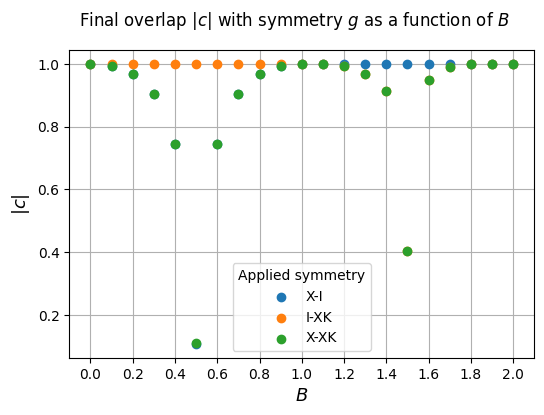

In [57]:
fig, ax = plt.subplots(figsize=(6,4))

for j, (col, label) in enumerate(zip(colors, symmetry_labels[1:])):
    plt.scatter(
        t_params,
        interior_scores[:, j],
        color=col,
        label = label
    )

ax.xaxis.set_major_locator(
    matplotlib.ticker.MultipleLocator(0.2)
)

#ax.set_yscale('log')

ax.grid()
ax.grid(
    which='minor',
    axis='y',
    linestyle='--',
    zorder=-1e10
)
ax.set_axisbelow(True)

ax.set_ylabel(r'$\vert c\vert$', fontsize=13)
ax.set_xlabel('$B$', fontsize=13)

ax.legend(loc='lower center', title='Applied symmetry')

fig.suptitle(r'Final overlap $\vert c \vert$ with symmetry $g$ as a function of $B$')

#fig.savefig(r'plots/ed_cost_function_from_svd_bosonic.png', dpi=200)

In [58]:
proj_rep_phases = list()

for t in tqdm(t_params):
    psi = psi_dict[t]

    rdm = generate_problem_rdm(
        psi,
        [],
        leftmost_symmetry_site,
        num_symmetry_sites,
        num_boundary_sites
    )

    left_rdm = (
        rdm
        .trace('b_right', 'k_right')
        .transpose('k_left', 'b_left')
        .data
    )
    right_rdm = (
        rdm
        .trace('b_left', 'k_left')
        .transpose('k_right', 'b_right')
        .data
    )

    unitary_pairs = [interior_results_dict[(t, i)][0] for i in [1,2,3]]
    left_unitaries, right_unitaries = zip(*unitary_pairs)

    left_unitaries = [
        lu.transpose('b_left', 'k_left').data
        for lu in left_unitaries
    ]
    right_unitaries = [
        ru.transpose('b_right', 'k_right').data
        for ru in right_unitaries
    ]

    left_phases = get_interior_proj_rep_phases(
        left_rdm,
        left_unitaries
    )
    right_phases = get_interior_proj_rep_phases(
        right_rdm,
        right_unitaries
    )

    proj_rep_phases.append([left_phases, right_phases])

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 21/21 [00:21<00:00,  1.02s/it]


In [59]:
proj_rep_phases = np.array(proj_rep_phases)

In [60]:
proj_rep_phases.shape

(21, 2, 9)

In [67]:
proj_rep_phases.shape

(21, 2, 9)

In [66]:
np.round(proj_rep_phases, 3)

array([[[-0.98 +0.199j, -1.   +0.j   ,  1.   +0.j   , -0.495+0.869j,
         -0.658+0.753j,  0.658+0.753j,  0.495+0.869j,  0.658-0.753j,
          0.495+0.869j],
        [-0.98 -0.199j, -1.   -0.j   ,  1.   -0.j   , -0.495-0.869j,
         -0.658-0.753j,  0.658-0.753j,  0.495-0.869j,  0.658+0.753j,
          0.495-0.869j]],

       [[ 0.776+0.631j, -1.   +0.j   ,  1.   -0.j   ,  0.923-0.386j,
         -0.473+0.881j,  0.473+0.881j, -0.923-0.386j,  0.473-0.881j,
         -0.923-0.386j],
        [ 0.776-0.631j, -1.   +0.j   ,  1.   -0.j   ,  0.923+0.386j,
         -0.473-0.881j,  0.473-0.881j, -0.923+0.386j,  0.473+0.881j,
         -0.923+0.386j]],

       [[ 0.257-0.966j, -1.   +0.j   ,  1.   +0.j   ,  0.163-0.987j,
         -0.995+0.096j,  0.995+0.096j, -0.163-0.987j,  0.995-0.096j,
         -0.163-0.987j],
        [ 0.257+0.966j, -1.   -0.j   ,  1.   -0.j   ,  0.163+0.987j,
         -0.995-0.096j,  0.995-0.096j, -0.163+0.987j,  0.995+0.096j,
         -0.163+0.987j]],

       [[-0.898+

In [81]:
def omega_lookup(proj_rep_phases_array, g, h):
    if (g == identity_element) or (h == identity_element):
        return np.ones(shape=proj_rep_phases_array.shape[:-1], dtype=np.complex128)
    index = next(
        i for i, (a,b,c) in enumerate(group_products)
        if (a,b) == (g,h)
    )

    return proj_rep_phases_array[..., index]

In [77]:
def cocyle_check(proj_rep_phases_array, g, h, k):
    X = omega_lookup(proj_rep_phases_array, h, k)
    if antilinear_dict[g]:
        X = X.conj()

    cocycle_array = (
        X*omega_lookup(proj_rep_phases_array, g, group_products_dict[(h,k)])
        /(
            omega_lookup(proj_rep_phases_array, g, h)
            *omega_lookup(proj_rep_phases_array, group_products_dict[(g,h)], k)
        )
    )

    return cocycle_array

In [84]:
def check_cocycle_equation(proj_rep_phases_array):
    arrays = list()

    for g,h,k in product(symmetry_labels[1:], repeat=3):
        arrays.append(cocyle_check(proj_rep_phases_array, g,h,k))

    out = np.stack(arrays, axis=-1)

    return out

In [87]:
cocycle_check_array = check_cocycle_equation(proj_rep_phases)

In [90]:
np.linalg.norm(cocycle_check_array - 1)

0.10608555723167644

In [93]:
np.max(np.abs(cocycle_check_array - 1))

0.04334291347606537

So indeed, satisfies a cocycle! It looks like the phases are classified by $\omega(g,g)$ terms.